In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.rcParams['savefig.dpi'] = 600
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11

In [166]:
s_with_aa = pd.read_csv("Supp_data/s_300_with_aa.csv")
data_150_CDS = pd.read_csv("s_final/Final_s_150_CDS.csv")

# Keeping only the samples with 5-FC selection
data_150_CDS = data_150_CDS[data_150_CDS['Condition'] == 'WITH_5FC'].copy().reset_index(drop=True)

# Selecting columns of interest
data_150_CDS = data_150_CDS[['Library', 'Alias', 'Genotype', 'N_T0', 'N_T3']].copy()

# Merging the data
data_150_with_aa = pd.merge(data_150_CDS, s_with_aa[['Genotype', 'Num_codon', 'New_codon',
                                                     'Mut_aa', 'WT_codon', 'WT_aa']].copy(),
                           on=['Genotype'], how='left')

# Keeping only the genotype which were considered in the final set
data_150_with_aa = data_150_with_aa.dropna(subset='Num_codon').copy().reset_index(drop=True)

In [168]:
# Total reads per amino acid variant
aa_variants = data_150_with_aa.copy().drop(columns=['Genotype', 'New_codon', 'WT_codon'])
aa_variants = aa_variants.groupby(by=['Library', 'Alias', 'Num_codon', 'Mut_aa', 'WT_aa'], as_index=False).sum()

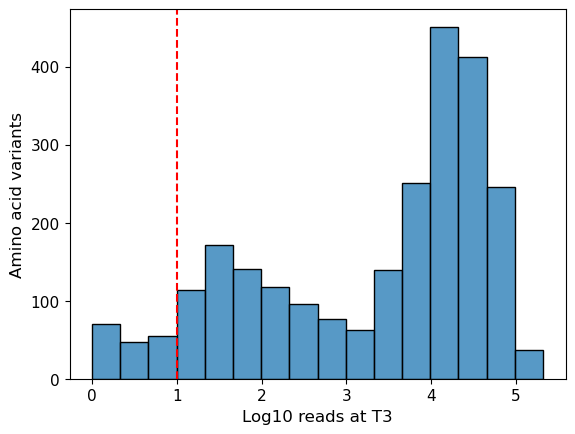

In [173]:
aa_variants['Log10_T3'] = np.log10(aa_variants['N_T3'])
sns.histplot(aa_variants, x='Log10_T3')
plt.axvline(x=1, linestyle='--', c='red')

plt.gca().set_ylabel('Amino acid variants')
plt.gca().set_xlabel('Log10 reads at T3')

depth_comp = plt.gcf()
depth_comp.savefig(f"Supp_figs/Seq_depth_comparison.png", bbox_inches='tight')

In [159]:
# Number of aa variants with less than 10 reads at T3
aa_variants[aa_variants['N_T3'] < 10].shape[0]

172

In [161]:
# Total Number of aa variants with less than 10 reads at T3
aa_variants.shape[0]

2486